# Digital Economy Intelligence Lab — Team 1
**Countries:** Mexico, South Korea, Finland, Brazil, India · **Sector:** Telecommunications  
**Team 1:** Valeria Hernandez, Lorena Perez, Gustavo Fuentes, Jose Pech, Julio de Aquino, Ricardo Horta  
**Professor:** Jose Francisco Perez Alcocer

**Challenge.** How prepared is each economy to participate in, generate and capture value in the digital economy, and what are Mexico's main strengths and gaps against the other four?

**Reproducibility.** Run the cells from top to bottom (`pip install -r requirements.txt` first). The first code cell runs `build_analysis.py`, which reads the untouched official files in `data/raw/` (it downloads them only if they are missing), selects the observation year for each indicator, builds `data/processed/digital_economy_clean.csv`, `source_log.csv`, `data_dictionary.csv` and the dashboard. Every later cell reads those outputs, so every figure in this notebook can be traced back to a raw file.

Section numbers follow the activity instructions (Part I, sections 1–12).

In [1]:
from pathlib import Path
import os, json, runpy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
os.chdir(ROOT)
runpy.run_path('build_analysis.py', run_name='__main__')

df = pd.read_csv('data/processed/digital_economy_clean.csv')
log = pd.read_csv('source_log.csv')
dictionary = pd.read_csv('data_dictionary.csv')
INDICATORS = list(log['variable'])
SHORT = {
    'fixed_broadband_per_100': 'Fixed broadband /100',
    'mobile_subscriptions_per_100': 'Mobile subs /100',
    'internet_users_pct': 'Internet users %',
    'secure_servers_per_million': 'Secure servers /1M',
    'ict_service_exports_pct': 'ICT service exports %',
    'high_tech_exports_pct': 'High-tech exports %',
    'rd_expenditure_pct_gdp': 'R&D % GDP',
    'resident_patent_applications': 'Resident patents',
}
COLORS = {'KOR': '#241854', 'FIN': '#5C3499', 'BRA': '#8B5FBF', 'IND': '#B79EDD', 'MEX': '#C9508A'}
pd.set_option('display.max_colwidth', 90)
pd.set_option('display.width', 160)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})

Created C:\Users\PC XPG MERA\Documents\GitHub\DE-a2-mexico-vrs-4-countries-team1\data\processed\digital_economy_clean.csv with 5 countries and 8 indicators.


## 1. Data acquisition and integration

**Procedure (reproducible).** Each series is requested from the World Bank Indicators API for the five ISO codes at once:

`https://api.worldbank.org/v2/country/MEX;KOR;FIN;BRA;IND/indicator/<CODE>?format=json&per_page=1000`

For each indicator the script also requests its official metadata (`https://api.worldbank.org/v2/indicator/<CODE>?format=json`), which gives the official definition and the original producer. Responses are stored in `data/raw/` and never edited; the access time of every file is kept in `data/download_log.csv`. Anyone can repeat the process by deleting `data/raw/` and running `python build_analysis.py`.

**Separation of files.** `data/raw/` holds only the original API responses; `data/processed/` holds only the integrated dataset produced by the script.

*Note on the eight data files:* they were saved in the first commit as indented JSON of the API response (same content, different whitespace), and their exact download time was not recorded; the log records the first-commit time as an upper bound. The script now saves response bytes exactly as received for any new download.

In [2]:
raw_files = sorted(p.name for p in Path('data/raw').glob('*.json'))
print(f'{len(raw_files)} files in data/raw/:')
print('\n'.join('  ' + f for f in raw_files))
display(pd.read_csv('data/download_log.csv')[['file', 'accessed_utc']])

assert sorted(df['country_code']) == sorted(['MEX', 'KOR', 'FIN', 'BRA', 'IND'])
assert len(INDICATORS) == 8
print(f'Integrated dataset: {df.shape[0]} economies x {df.shape[1]} columns '
      f'(8 indicators + 8 observation years + 8 normalised scores + DRS + 2 identifiers)')
df[['country'] + INDICATORS]

16 files in data/raw/:
  world_bank_BX.GSR.CCIS.ZS.json
  world_bank_GB.XPD.RSDV.GD.ZS.json
  world_bank_IP.PAT.RESD.json
  world_bank_IT.CEL.SETS.P2.json
  world_bank_IT.NET.BBND.P2.json
  world_bank_IT.NET.SECR.P6.json
  world_bank_IT.NET.USER.ZS.json
  world_bank_TX.VAL.TECH.MF.ZS.json
  world_bank_metadata_BX.GSR.CCIS.ZS.json
  world_bank_metadata_GB.XPD.RSDV.GD.ZS.json
  world_bank_metadata_IP.PAT.RESD.json
  world_bank_metadata_IT.CEL.SETS.P2.json
  world_bank_metadata_IT.NET.BBND.P2.json
  world_bank_metadata_IT.NET.SECR.P6.json
  world_bank_metadata_IT.NET.USER.ZS.json
  world_bank_metadata_TX.VAL.TECH.MF.ZS.json


,file,accessed_utc
0,data/raw/world_bank_BX.GSR.CCIS.ZS.json,2026-09-28T22:57:19Z
1,data/raw/world_bank_GB.XPD.RSDV.GD.ZS.json,2026-09-28T22:57:19Z
2,data/raw/world_bank_IP.PAT.RESD.json,2026-09-28T22:57:19Z
3,data/raw/world_bank_IT.CEL.SETS.P2.json,2026-09-28T22:57:19Z
4,data/raw/world_bank_IT.NET.BBND.P2.json,2026-09-28T22:57:19Z
5,data/raw/world_bank_IT.NET.SECR.P6.json,2026-09-28T22:57:19Z
6,data/raw/world_bank_IT.NET.USER.ZS.json,2026-09-28T22:57:19Z
7,data/raw/world_bank_TX.VAL.TECH.MF.ZS.json,2026-09-28T22:57:19Z
8,data/raw/world_bank_metadata_BX.GSR.CCIS.ZS.json,2026-09-30T03:16:57Z
9,data/raw/world_bank_metadata_GB.XPD.RSDV.GD.ZS.json,2026-09-30T03:16:57Z


Integrated dataset: 5 economies x 27 columns (8 indicators + 8 observation years + 8 normalised scores + DRS + 2 identifiers)


,country,fixed_broadband_per_100,mobile_subscriptions_per_100,internet_users_pct,secure_servers_per_million,ict_service_exports_pct,high_tech_exports_pct,rd_expenditure_pct_gdp,resident_patent_applications
0,South Korea,47.801497,172.520241,97.895638,11902.383072,12.468605,36.258256,4.94352,186245.0
1,Finland,36.476534,125.860955,93.724052,177933.600728,32.783102,9.285227,3.09380,1557.0
2,Brazil,24.079199,101.926846,84.463472,6941.174080,13.672628,11.110364,1.19380,4666.0
3,India,3.150463,79.352692,64.943497,1212.441661,48.595548,18.572395,0.64558,26267.0
4,Mexico,21.736723,116.486713,83.122338,531.655698,5.088863,19.303760,0.26746,1117.0


## 2. Selection of the eight indicators

| Required block | Indicator | Why it belongs there | Known limitation |
|---|---|---|---|
| Infrastructure / connectivity (2) | Fixed broadband subscriptions per 100 people | Installed high-capacity fixed access (≥ 256 kbit/s) | Counts subscriptions, not households or speed |
| | Mobile cellular subscriptions per 100 people | Reach of the mobile network, the main access route in emerging economies | Can exceed 100 because of multiple SIMs per person |
| Access / use (1) | Individuals using the Internet (% of population) | Whether people actually go online, independent of the technology | Survey-based; says nothing about intensity of use |
| Quality / affordability (1) | Secure Internet servers per 1 million people | Quality **proxy**: density of publicly trusted TLS certificates, i.e. of secure hosting for e-commerce, banking and government services | Counted by *hosting* country, so it also reflects where data centres sit; it does not measure speed or price. Affordability is **not** covered by the eight indicators (see §10) |
| Digital economic activity (2) | ICT service exports (% of service exports) | Digital services sold abroad: computer, telecom and information services | A share: it depends on the size of the other service exports |
| | High-technology exports (% of manufactured exports) | Trade in R&D-intensive goods, including computers and electronics | Includes aerospace and pharmaceuticals; assembly-based exports count fully |
| Technological capacity / innovation (2) | R&D expenditure (% of GDP) | Resources a country invests in creating technology | Input, not output |
| | Patent applications, residents | Output of domestic inventive activity | Counts attempts, not quality or commercial use |

All eight exist for the five economies in the selected years, so no missing-data treatment was needed (the pipeline stops instead of imputing if a value is absent).

**Sources.** The eight series were acquired through the World Bank Indicators API, one of the listed official platforms. The API metadata (column `original_producer` in `source_log.csv`) identifies who produces each series:
- **ITU** (World Telecommunication/ICT Indicators Database, the data behind ITU DataHub): fixed broadband, mobile subscriptions, internet users.
- **WIPO** (WIPO IP Statistics): resident patent applications.
- **World Bank** compilations from Netcraft, IMF Balance of Payments, UN Comtrade/WITS and UNESCO UIS: secure servers, ICT service exports, high-tech exports, R&D.

Together, the eight indicators therefore come from **three of the listed organisations: ITU, the World Bank and WIPO**, with the WDI API as the single, reproducible delivery channel.

In [3]:
log[['variable', 'category', 'official_indicator', 'unit', 'original_producer']]

,variable,category,official_indicator,unit,original_producer
0,fixed_broadband_per_100,Infrastructure / connectivity,Fixed broadband subscriptions (per 100 people),subscriptions per 100 people,"World Telecommunication/ICT Indicators Database, International Telecommunication Union..."
1,mobile_subscriptions_per_100,Infrastructure / connectivity,Mobile cellular subscriptions (per 100 people),subscriptions per 100 people,"World Telecommunication/ICT Indicators Database, International Telecommunication Union..."
2,internet_users_pct,Access / use,Individuals using the Internet (% of population),% of population,"World Telecommunication/ICT Indicators Database, International Telecommunication Union..."
3,secure_servers_per_million,Quality / affordability (quality proxy),Secure Internet servers (per 1 million people),per 1 million people,"Secure Server Survey, Netcraft, uri: http://www.netcraft.com/; World Bank population e..."
4,ict_service_exports_pct,Digital economic activity,"ICT service exports (% of service exports, BoP)",% of service exports,"Balance of Payments Statistics Yearbook and data files, International Monetary Fund (IMF)"
5,high_tech_exports_pct,Digital economic activity,High-technology exports (% of manufactured exports),% of manufactured exports,"Comtrade database, United Nations (UN), uri: comtrade.un.org, publisher: UN Statistics..."
6,rd_expenditure_pct_gdp,Technological capacity / innovation,Research and development expenditure (% of GDP),% of GDP,"Stat Bulk Data Download Service, UN Educational, Scientific and Cultural Organization ..."
7,resident_patent_applications,Technological capacity / innovation,"Patent applications, residents",count,"WIPO Patent Report: Statistics on Worldwide Patent Activity, World Intellectual Proper..."


## 3. Record and traceability

`source_log.csv` records, for every indicator: official name, **official definition** (from the API metadata), unit, original producer, delivery channel, API endpoint, metadata endpoint, link to the original source, raw file, access date, reference year, the observation year of each country, year exceptions, acquisition method, transformation and missing-data treatment. `data_dictionary.csv` documents all 27 columns of the clean dataset, including type and unit.

The cell below traces one value of the clean dataset back to its raw record.

In [4]:
print('source_log.csv fields:', ', '.join(log.columns))
print('data_dictionary.csv covers', len(dictionary), 'of', df.shape[1], 'dataset columns\n')

var, iso = 'fixed_broadband_per_100', 'MEX'
entry = log.set_index('variable').loc[var]
clean = df.set_index('country_code').loc[iso]
records = json.loads(Path(entry['raw_file']).read_text(encoding='utf-8'))[1]
raw = next(r for r in records if r['countryiso3code'] == iso and int(r['date']) == clean[f'{var}_year'])
print(f"Clean value : {clean[var]} ({var}, {iso}, year {clean[f'{var}_year']})")
print(f"Raw record  : {entry['raw_file']} -> date={raw['date']}, value={raw['value']}")
print(f"Indicator   : {entry['official_indicator']} [{entry['indicator_code']}], unit: {entry['unit']}")
print(f"Producer    : {entry['original_producer']}")
print(f"Endpoint    : {entry['api_endpoint']}")

source_log.csv fields: variable, official_indicator, indicator_code, category, definition, unit, original_producer, delivery_channel, api_endpoint, metadata_endpoint, origin_url, raw_file, accessed_utc, reference_year, observation_years, year_exceptions, method, transformation, missing_data_treatment
data_dictionary.csv covers 27 of 27 dataset columns

Clean value : 21.7367225364543 (fixed_broadband_per_100, MEX, year 2024)
Raw record  : data/raw/world_bank_IT.NET.BBND.P2.json -> date=2024, value=21.7367225364543
Indicator   : Fixed broadband subscriptions (per 100 people) [IT.NET.BBND.P2], unit: subscriptions per 100 people
Producer    : World Telecommunication/ICT Indicators Database, International Telecommunication Union (ITU)
Endpoint    : https://api.worldbank.org/v2/country/MEX;KOR;FIN;BRA;IND/indicator/IT.NET.BBND.P2?format=json&per_page=1000


## 4. Temporal comparability

**Rule.** For each indicator the *reference year* is the latest year reported by at least four of the five economies; every economy uses that year. An economy that has not published the reference year uses its latest earlier observation, and the exception is written in `source_log.csv` (`year_exceptions`). The year of every value is kept in the `<indicator>_year` columns.

In [5]:
years = df.set_index('country')[[f'{i}_year' for i in INDICATORS]]
years.columns = [SHORT[i] for i in INDICATORS]
display(years.T)
display(log[['variable', 'reference_year', 'year_exceptions']])

country,South Korea,Finland,Brazil,India,Mexico
Fixed broadband /100,2024,2024,2024,2024,2024
Mobile subs /100,2024,2024,2024,2024,2024
Internet users %,2024,2024,2024,2024,2024
Secure servers /1M,2024,2024,2024,2024,2024
ICT service exports %,2025,2025,2025,2025,2025
High-tech exports %,2024,2024,2024,2024,2024
R&D % GDP,2023,2023,2023,2020,2023
Resident patents,2021,2021,2021,2021,2021


,variable,reference_year,year_exceptions
0,fixed_broadband_per_100,2024,none
1,mobile_subscriptions_per_100,2024,none
2,internet_users_pct,2024,none
3,secure_servers_per_million,2024,none
4,ict_service_exports_pct,2025,none
5,high_tech_exports_pct,2024,none
6,rd_expenditure_pct_gdp,2023,India: 2020 (latest available; 2023 not reported)
7,resident_patent_applications,2021,none


Only one exception remains: **India's R&D expenditure is from 2020**, against 2023 for the other four. (Before this rule, India's internet use was taken from 2025 while the others were 2024, and Mexico's R&D from 2024 while the others were 2023.)

**What can go wrong when years differ.** A value from a different year mixes a real difference between countries with the change that happened over time.
- *Fast-moving indicators are the most exposed.* India's internet use rose from 64.9% (2024) to 70.0% (2025): comparing India's 2025 value with the others' 2024 values would add about 5 points that are only time, not country difference. Secure servers grow even faster (Mexico: 349 per million in 2021, 532 in 2024, +52%).
- *Slow-moving indicators are less exposed.* R&D intensity changes slowly (India: 0.67% in 2017, 0.65% in 2020), so India's 2020 value is a reasonable, though imperfect, stand-in. It becomes misleading if India's R&D changed sharply after 2020, which we cannot verify with this data.
- *Shocks.* The latest patent year for everyone is 2021, a pandemic-affected year; all five share it, so the comparison is consistent, but it is not a normal year.
- *Different indicators, different years.* ICT service exports are from 2025, patents from 2021. The DRS combines them; it is a snapshot of "latest comparable data", not of one calendar year.

In [6]:
def load_panel():
    rows = []
    for _, r in log.iterrows():
        for rec in json.loads(Path(r['raw_file']).read_text(encoding='utf-8'))[1]:
            rows.append({'indicator': r['variable'], 'iso': rec['countryiso3code'],
                         'year': int(rec['date']), 'value': rec['value']})
    return pd.DataFrame(rows)

panel = load_panel()
pick = lambda ind, y0: panel[(panel.indicator == ind) & (panel.year >= y0)].pivot(index='year', columns='iso', values='value')
print('Internet users (%), 2021-2025'); display(pick('internet_users_pct', 2021).round(1))
print('R&D expenditure (% of GDP), 2017-2024'); display(pick('rd_expenditure_pct_gdp', 2017).round(2))

Internet users (%), 2021-2025


iso,BRA,FIN,IND,KOR,MEX
year,,,,,
2021,80.7,92.8,49.3,97.6,75.6
2022,80.5,93.0,55.9,97.2,78.6
2023,84.2,93.5,60.3,97.4,81.2
2024,84.5,93.7,64.9,97.9,83.1
2025,NaN,NaN,70.0,NaN,NaN


R&D expenditure (% of GDP), 2017-2024


iso,BRA,FIN,IND,KOR,MEX
year,,,,,
2017,1.12,2.75,0.67,4.07,0.32
2018,1.15,2.78,0.66,4.27,0.30
2019,1.15,2.82,0.66,4.36,0.28
2020,1.22,2.93,0.65,4.52,0.29
2021,1.13,3.01,NaN,4.60,0.27
2022,1.19,2.98,NaN,4.85,0.26
2023,1.19,3.09,NaN,4.94,0.27
2024,NaN,NaN,NaN,NaN,0.25
2025,NaN,NaN,NaN,NaN,NaN


## 5. Exploration and preparation

### 5.1 Variable types

In [7]:
types = dictionary.set_index('variable').loc[['country_code', 'country'] + INDICATORS, ['type', 'unit']]
types['pandas dtype'] = df[types.index].dtypes.astype(str)
types

,type,unit,pandas dtype
variable,,,
country_code,categorical (text),code,str
country,categorical (text),text,str
fixed_broadband_per_100,continuous (ratio),subscriptions per 100 people,float64
mobile_subscriptions_per_100,continuous (ratio),subscriptions per 100 people,float64
internet_users_pct,continuous (ratio),% of population,float64
secure_servers_per_million,continuous (ratio),per 1 million people,float64
ict_service_exports_pct,continuous (ratio),% of service exports,float64
high_tech_exports_pct,continuous (ratio),% of manufactured exports,float64
rd_expenditure_pct_gdp,continuous (ratio),% of GDP,float64


The two identifiers are categorical; six indicators are continuous ratios (per 100 people, per million people, percentages) and resident patents is a count. The `_year` columns are integers and the `_norm` columns and the DRS are continuous scores between 0 and 1.

### 5.2 Missing values, and zero versus "not available"

In the API files a missing observation is `null`; a real zero is `0`. The pipeline treats them differently: `null` means *not available* and is never replaced; `0` is a valid observation.

In [8]:
print(f'Raw panel: {len(panel)} rows (8 indicators x 5 economies x {panel.year.nunique()} years, {panel.year.min()}-{panel.year.max()})')
print(f'  null (not available): {panel.value.isna().sum()}   observed zeros: {(panel.value == 0).sum()}\n')
print('Observed zeros by indicator (first and last year):')
display(panel[panel.value == 0].groupby('indicator').year.agg(['count', 'min', 'max']))
print('Nulls per economy, 2015-2025 window:')
window = panel[panel.year.between(2015, 2025)]
display(window.assign(null=window.value.isna()).pivot_table(index='indicator', columns='iso', values='null', aggfunc='sum'))
print('Selected snapshot -> nulls:', int(df[INDICATORS].isna().sum().sum()), '| zeros:', int((df[INDICATORS] == 0).sum().sum()))

Raw panel: 2640 rows (8 indicators x 5 economies x 66 years, 1960-2025)
  null (not available): 1389   observed zeros: 80

Observed zeros by indicator (first and last year):


,count,min,max
indicator,,,
internet_users_pct,3,1990,1990
mobile_subscriptions_per_100,77,1960,1994


Nulls per economy, 2015-2025 window:


iso,BRA,FIN,IND,KOR,MEX
indicator,,,,,
fixed_broadband_per_100,1,1,1,1,1
high_tech_exports_pct,1,1,1,1,1
ict_service_exports_pct,0,0,0,0,0
internet_users_pct,1,1,0,1,1
mobile_subscriptions_per_100,1,1,1,1,1
rd_expenditure_pct_gdp,2,2,5,2,1
resident_patent_applications,4,4,4,4,4
secure_servers_per_million,1,1,1,1,1


Selected snapshot -> nulls: 0 | zeros: 0


- Most nulls are years before an indicator existed (secure servers start in 2010, high-tech exports in 2007) or years not yet published (2025 for most series; patents after 2021).
- The 80 zeros are genuine: mobile subscriptions before mobile networks were launched (1960–1994) and internet use in 1990. They are true zeros, not gaps, and none of them is in the selected snapshot.
- The selected snapshot has **no missing values and no zeros**, so nothing had to be imputed.

### 5.3 Scales

In [9]:
x = df.set_index('country')[INDICATORS]
scales = x.describe().T[['min', '50%', 'max']]
scales['max/min'] = x.max() / x.min()
scales['skew'] = x.skew()
scales['unit'] = log.set_index('variable')['unit']
scales.round(2)

,min,50%,max,max/min,skew,unit
fixed_broadband_per_100,3.15,24.08,47.80,15.17,-0.24,subscriptions per 100 people
mobile_subscriptions_per_100,79.35,116.49,172.52,2.17,0.84,subscriptions per 100 people
internet_users_pct,64.94,84.46,97.90,1.51,-1.00,% of population
secure_servers_per_million,531.66,6941.17,177933.60,334.68,2.22,per 1 million people
ict_service_exports_pct,5.09,13.67,48.60,9.55,0.87,% of service exports
high_tech_exports_pct,9.29,18.57,36.26,3.90,1.33,% of manufactured exports
rd_expenditure_pct_gdp,0.27,1.19,4.94,18.48,0.96,% of GDP
resident_patent_applications,1117.00,4666.00,186245.00,166.74,2.15,count


Units range from percentages to counts in the hundreds of thousands, so the indicators must be rescaled before they are combined. Two indicators have extreme spreads: **secure servers (max/min ≈ 335)** and **resident patents (≈ 167)**. The next largest is R&D (≈ 18). Hence the rule used in §7: any indicator with max/min > 100 is log-transformed, ln(1 + x), before min–max scaling.

### 5.4 Extreme values

In [10]:
q1, q3 = x.quantile(.25), x.quantile(.75)
iqr = q3 - q1
flags = (x > q3 + 1.5 * iqr) | (x < q1 - 1.5 * iqr)
extremes = [(c, SHORT[i], round(x.loc[c, i], 1), round(x[i].median(), 1)) for i in INDICATORS for c in x.index if flags.loc[c, i]]
pd.DataFrame(extremes, columns=['country', 'indicator', 'value', 'median of five'])

,country,indicator,value,median of five
0,South Korea,Mobile subs /100,172.5,116.5
1,India,Internet users %,64.9,84.5
2,Finland,Secure servers /1M,177933.6,6941.2
3,South Korea,High-tech exports %,36.3,18.6
4,South Korea,Resident patents,186245.0,4666.0


With only five observations the Tukey rule (1.5 × IQR) is a rough guide, but it flags the values that matter: Finland's secure servers (177,934 per million, 26× the median), South Korea's patents (186,245), mobile subscriptions (172.5) and high-tech exports (36.3%), and India's low internet use (64.9%). They are **real observations, not errors**, so they are kept. Their influence on the index is limited by the log rule (secure servers, patents) and discussed in the robustness check in §7.

### 5.5 Inconsistencies and definitional issues
- **Mobile subscriptions above 100 per 100 people** (South Korea, Finland, Mexico, Brazil): the indicator counts SIM subscriptions, not people.
- **Secure servers are counted by hosting country**: Finland's value partly reflects large data centres hosted there, not only domestic service quality.
- **ICT service exports are a share of service exports**: India's 48.6% reflects the weight of IT services in its trade, not a larger absolute digital sector than South Korea's.
- **High-tech exports include assembly**: Mexico's 19.3% (2nd of five) mostly reflects manufacturing for export, and says little about domestic technological capability.
- **Patents are counted as applications by residents**: they measure invention attempts, not granted or commercialised inventions.
- **Mixed years**: see §4.

### 5.6 Preparation decisions

| Decision | Choice | Reason |
|---|---|---|
| Raw files | Stored in `data/raw/` and never edited | Traceability |
| Observation year | Common reference year (≥ 4 of 5 economies); one documented exception | Comparability (§4) |
| Missing values | None in the snapshot; the pipeline stops rather than imputes | No invented data |
| Zeros | Kept as real observations; distinguished from null | 0 ≠ not available |
| Outliers | Kept | They are real values |
| Skewed indicators | ln(1 + x) when max/min > 100 (secure servers, patents) | Avoid one country squeezing the others to 0 |
| Rescaling | Min–max to 0–1 across the five economies | Common scale (§7) |

## 6. Conceptual foundation

### A. ICT sector, digital economy and digitalised economy
- The **ICT sector** is the *producing* sector: firms that make ICT goods and services (equipment, telecom operators, software, IT services).
- The **digital economy** is the ICT sector plus the economic activity that depends mainly on digital inputs, data and platforms (e-commerce, digital services, platforms).
- The **digitalised economy** is the whole economy transformed by digital technologies, including traditional sectors that use them.

Our eight indicators best describe the **digital economy**: they go beyond the ICT sector (they include internet use and innovation capacity), but they do not measure digital adoption across traditional sectors (for example, firms using e-commerce or cloud services), which a digitalised-economy view would need.

### B. Growth of the digital economy
Three of our indicators show three different dimensions of digital growth:
- **Fixed broadband** measures the *infrastructure* that makes digital activity possible.
- **ICT service exports** measure *value capture*: whether a country sells digital services to the world.
- **R&D expenditure** measures *future capability*: investment in creating new technology.

A single indicator is not enough: India is first in ICT service exports but last in all three connectivity and use indicators; Mexico has more mobile subscriptions than people but is last in R&D. Each indicator captures one dimension, and digital development requires several at once.

### C. Indicator, evidence and interpretation
- **Observed data:** Mexico has **21.7 fixed broadband subscriptions per 100 people (2024)**, compared with 47.8 in South Korea, 36.5 in Finland and 24.1 in Brazil; only India (3.2) is lower.
- **Interpretation:** fixed high-capacity access is less widespread in Mexico than in three of the four peers.
- **Supported conclusion:** fixed broadband is a relative weakness of Mexico's connectivity base within this group.
- **Conclusion this data alone cannot justify:** that Mexican households lack internet access (many connect by mobile), that Mexico's broadband is slower or more expensive, or that low broadband *causes* lower productivity.

### D. Digital trade
- An **e-commerce transaction** is a purchase or sale *ordered* over computer networks, whatever is delivered. Example: a customer in Monterrey orders a phone from an online store and receives it by courier.
- A **digitally delivered service** is a service *supplied* over computer networks. Example: a Mexican software firm provides cloud-based accounting to a client in Chile, entirely online.

The difference is the delivery: an e-commerce order can be for a physical good, while a digitally delivered service never leaves the network.

## 7. Digital Readiness Score (DRS)

$$DRS = \sum_{k=1}^{8} w_k I_k, \qquad w_k = \tfrac{1}{8} = 0.125, \qquad \sum_k w_k = 1$$

| Choice | Decision | Justification |
|---|---|---|
| Normalisation | Min–max across the five economies: $I_k = (x - \min)/(\max - \min)$ | Bounded 0–1 and easy to read (0 = lowest of the five, 1 = highest). Its weakness is sensitivity to extremes, handled with the log rule |
| Transformation | ln(1 + x) before scaling when max/min > 100 (secure servers, patents) | Without it Finland (secure servers) and South Korea (patents) would compress the other four towards 0 |
| Direction | All eight are positive (more = more readiness) | None measures a cost. Mobile subscriptions above 100 still indicate wider mobile reach, so they are not inverted |
| Weights | Equal, 1/8 each | No defensible basis for ranking the dimensions; equal weights are transparent. Robustness below |
| Missing data | None; the pipeline would stop rather than impute | No invented values |

In [11]:
norm_cols = [f'{i}_norm' for i in INDICATORS]
weights = pd.Series(0.125, index=INDICATORS)
assert np.isclose(weights.sum(), 1)
scores = df.set_index('country')[norm_cols]
scores.columns = [SHORT[i] for i in INDICATORS]
drs = (scores * weights.values).sum(axis=1)
assert np.allclose(drs, df.set_index('country')['digital_readiness_score'])
display(scores.round(3).assign(DRS=drs.round(3)).sort_values('DRS', ascending=False))
display(log[['variable', 'transformation']])

,Fixed broadband /100,Mobile subs /100,Internet users %,Secure servers /1M,ICT service exports %,High-tech exports %,R&D % GDP,Resident patents,DRS
country,,,,,,,,,
South Korea,1.000,1.000,1.000,0.535,0.170,1.000,1.000,1.000,0.838
Finland,0.746,0.499,0.873,1.000,0.637,0.000,0.604,0.065,0.553
Brazil,0.469,0.242,0.592,0.442,0.197,0.068,0.198,0.279,0.311
India,0.000,0.000,0.000,0.142,1.000,0.344,0.081,0.617,0.273
Mexico,0.416,0.399,0.552,0.000,0.000,0.371,0.000,0.000,0.217


,variable,transformation
0,fixed_broadband_per_100,none (max/min = 15.2 <= 100)
1,mobile_subscriptions_per_100,none (max/min = 2.2 <= 100)
2,internet_users_pct,none (max/min = 1.5 <= 100)
3,secure_servers_per_million,ln(1 + x) before normalisation (max/min = 335 > 100)
4,ict_service_exports_pct,none (max/min = 9.5 <= 100)
5,high_tech_exports_pct,none (max/min = 3.9 <= 100)
6,rd_expenditure_pct_gdp,none (max/min = 18.5 <= 100)
7,resident_patent_applications,ln(1 + x) before normalisation (max/min = 167 > 100)


**Robustness.** Because the weights are a choice, we recompute the ranking (a) dropping each indicator in turn, (b) giving equal weight to the five required blocks instead of the eight indicators, and (c) using z-scores instead of min–max.

In [12]:
nrm = df.set_index('country')[norm_cols]
variants = {'Baseline (equal weights)': nrm.mean(axis=1)}
for i in INDICATORS:
    variants[f'without {SHORT[i]}'] = nrm.drop(columns=f'{i}_norm').mean(axis=1)
blocks = {'connectivity': INDICATORS[0:2], 'use': INDICATORS[2:3], 'quality': INDICATORS[3:4], 'activity': INDICATORS[4:6], 'innovation': INDICATORS[6:8]}
variants['equal weight per block'] = sum(nrm[[f'{i}_norm' for i in v]].mean(axis=1) for v in blocks.values()) / len(blocks)
logged = x.copy()
for i in log.loc[log['transformation'].str.startswith('ln'), 'variable']:
    logged[i] = np.log1p(logged[i])
variants['z-scores'] = ((logged - logged.mean()) / logged.std()).mean(axis=1)
ranks = pd.DataFrame({k: v.rank(ascending=False).astype(int) for k, v in variants.items()}).T
ranks[['South Korea', 'Finland', 'Brazil', 'India', 'Mexico']]

country,South Korea,Finland,Brazil,India,Mexico
Baseline (equal weights),1,2,3,4,5
without Fixed broadband /100,1,2,4,3,5
without Mobile subs /100,1,2,3,4,5
without Internet users %,1,2,4,3,5
without Secure servers /1M,1,2,3,4,5
without ICT service exports %,1,2,3,5,4
without High-tech exports %,1,2,3,4,5
without R&D % GDP,1,2,3,4,5
without Resident patents,1,2,3,5,4
equal weight per block,1,2,3,4,5


South Korea and Finland are first and second in every variant. Mexico is last in 9 of 11 variants; it moves to 4th, above India, only when ICT service exports or resident patents are removed, the two indicators where India is strong. **The robust conclusion is that Mexico belongs to the lower group with Brazil and India, and is usually its lowest member; the order inside that group is sensitive to weighting.**

## 8. Visualisation

Four charts, each answering a different question. The same charts, with the same readings, are in the dashboard (`dashboard/index.html`).

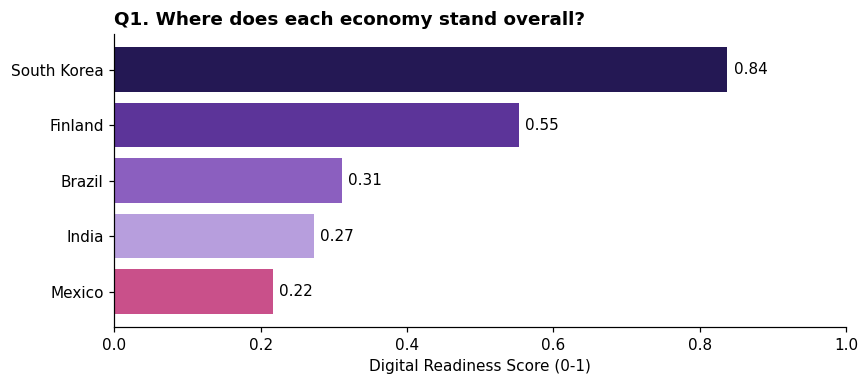

In [13]:
d = df.sort_values('digital_readiness_score')
fig, ax = plt.subplots(figsize=(8, 3.6))
bars = ax.barh(d['country'], d['digital_readiness_score'], color=[COLORS[c] for c in d['country_code']])
ax.bar_label(bars, fmt='%.2f', padding=4)
ax.set_xlim(0, 1)
ax.set_xlabel('Digital Readiness Score (0-1)')
ax.set_title('Q1. Where does each economy stand overall?', loc='left', fontweight='bold')
plt.tight_layout(); plt.show()

**What do I observe?** South Korea leads (0.84), followed by Finland (0.55). Brazil (0.31), India (0.27) and Mexico (0.22) form a lower group. Mexico is 5th of 5, 0.62 points below the leader and 0.09 below Brazil.

**What does it mean?** On these eight indicators, Mexico's digital readiness is closer to the emerging-economy peers than to the two advanced benchmarks, and it is the lowest of the group.

**What can't I conclude?** The score is relative to these five countries and depends on equal weights; the order of Brazil, India and Mexico changes with some weighting choices (§7), so the bottom three are not clearly separated. The DRS does not measure affordability, speed, skills or compute, and it says nothing about causes.

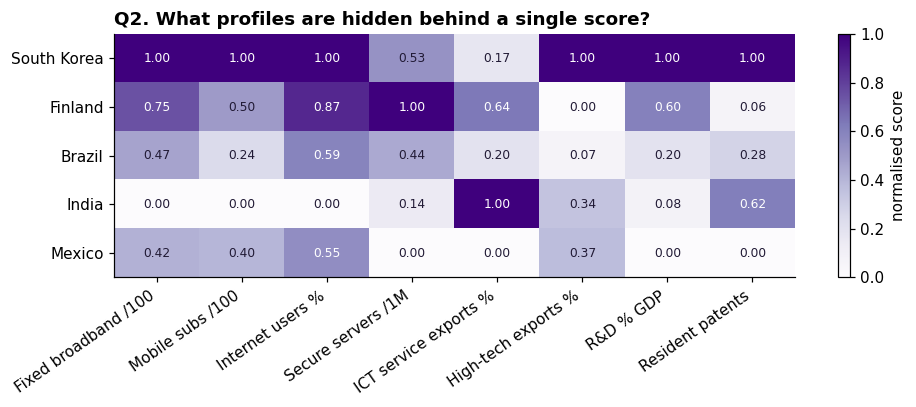

In [14]:
h = df.set_index('country').loc[['South Korea', 'Finland', 'Brazil', 'India', 'Mexico'], norm_cols]
fig, ax = plt.subplots(figsize=(9, 3.8))
im = ax.imshow(h.values, cmap='Purples', vmin=0, vmax=1, aspect='auto')
ax.set_xticks(range(8), [SHORT[i] for i in INDICATORS], rotation=35, ha='right')
ax.set_yticks(range(5), h.index)
for r in range(5):
    for c in range(8):
        v = h.values[r, c]
        ax.text(c, r, f'{v:.2f}', ha='center', va='center', fontsize=8, color='white' if v > .55 else '#211A35')
fig.colorbar(im, ax=ax, label='normalised score')
ax.set_title('Q2. What profiles are hidden behind a single score?', loc='left', fontweight='bold')
plt.tight_layout(); plt.show()

**What do I observe?** South Korea scores highest in 6 of 8 indicators. Finland leads in secure servers, and India leads in ICT service exports (48.6% of service exports) while being last in all three connectivity and use indicators. Mexico scores 0 (lowest of the five) in four indicators (secure servers, ICT service exports, R&D and patents) and 0.37–0.55 in connectivity, use and high-tech exports.

**What does it mean?** Close DRS values hide very different profiles. India's score comes from digital trade and patent volume, Brazil's from a fairly even spread, and Mexico's almost entirely from connectivity, use and high-tech exports.

**What can't I conclude?** A 0 means "lowest of these five", not absence. The same difference in normalised score does not mean the same thing across indicators, and the chart hides absolute gaps: Mexico's 0 in secure servers is 532 per million, against Brazil's 6,941.

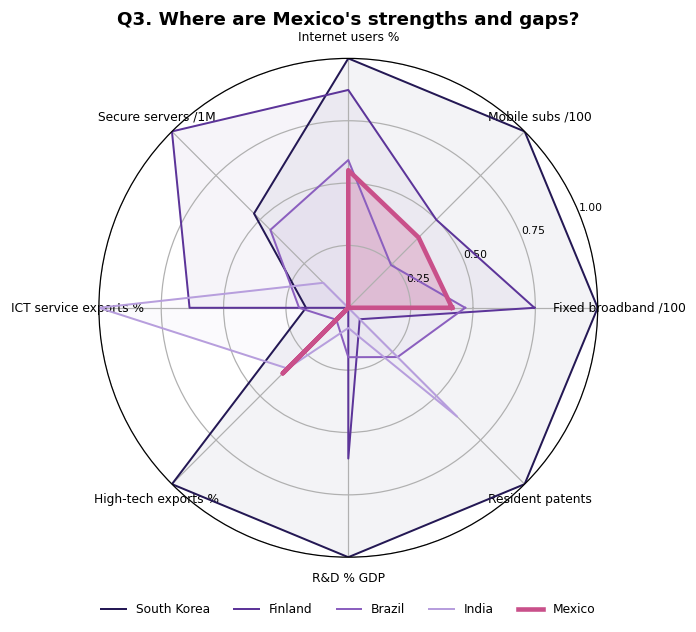

In [15]:
theta = np.linspace(0, 2 * np.pi, 8, endpoint=False).tolist()
fig, ax = plt.subplots(figsize=(6.4, 6.4), subplot_kw={'polar': True})
for _, r in df.iterrows():
    vals = [r[c] for c in norm_cols]
    mex = r['country_code'] == 'MEX'
    ax.plot(theta + theta[:1], vals + vals[:1], color=COLORS[r['country_code']], lw=3 if mex else 1.3, label=r['country'])
    ax.fill(theta + theta[:1], vals + vals[:1], color=COLORS[r['country_code']], alpha=.25 if mex else .05)
ax.set_xticks(theta, [SHORT[i] for i in INDICATORS], fontsize=8)
ax.set_ylim(0, 1); ax.set_yticks([.25, .5, .75, 1]); ax.tick_params(axis='y', labelsize=7)
ax.legend(loc='upper center', bbox_to_anchor=(.5, -.07), ncol=5, frameon=False, fontsize=8)
ax.set_title("Q3. Where are Mexico's strengths and gaps?", fontweight='bold', pad=22)
plt.tight_layout(); plt.show()

**What do I observe?** Mexico's profile extends only on the connectivity side. It is 3rd of five in mobile subscriptions (116.5 per 100, ahead of Brazil and India) and 4th in fixed broadband and internet use. It is also 2nd in high-tech exports (19.3%). On innovation and digital activity it collapses to the centre: it is last in R&D, resident patents, ICT service exports and secure servers.

**What does it mean?** Mexico has a moderate connectivity base, led by mobile, but has not turned it into technological capacity or digital exports. Its main gap is innovation and digital value capture, not network access.

**What can't I conclude?** The shape and area of a radar depend on the order of the axes and are not the DRS. High-tech exports largely reflect assembly for export and do not prove domestic digital capability. Being ahead of India does not mean Mexico's connectivity is sufficient in absolute terms.

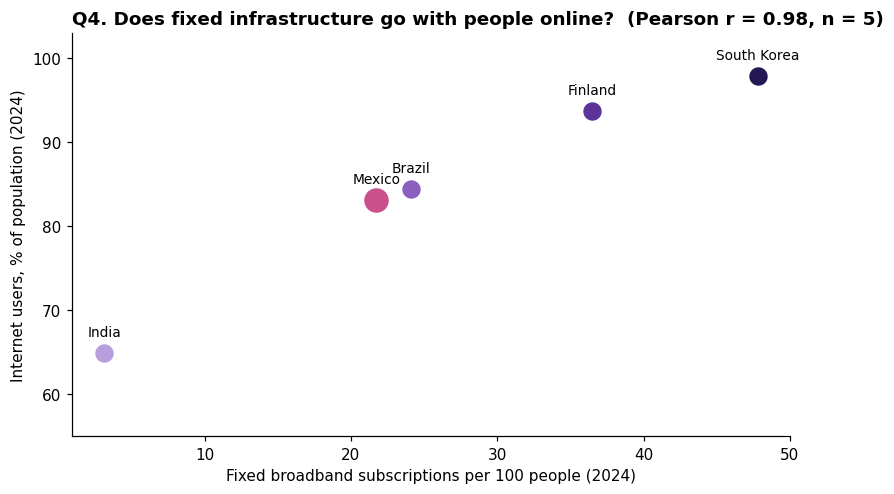

In [16]:
fig, ax = plt.subplots(figsize=(7.5, 4.6))
for _, r in df.iterrows():
    mex = r['country_code'] == 'MEX'
    ax.scatter(r['fixed_broadband_per_100'], r['internet_users_pct'], s=170, color=COLORS[r['country_code']],
               edgecolor='#C9508A' if mex else 'white', linewidth=3 if mex else 1, zorder=3)
    ax.annotate(r['country'], (r['fixed_broadband_per_100'], r['internet_users_pct']), xytext=(0, 11),
                textcoords='offset points', ha='center', fontsize=9)
ax.set_xlabel('Fixed broadband subscriptions per 100 people (2024)')
ax.set_ylabel('Internet users, % of population (2024)')
ax.set_ylim(55, 103)
r_p = df['fixed_broadband_per_100'].corr(df['internet_users_pct'])
ax.set_title(f'Q4. Does fixed infrastructure go with people online?  (Pearson r = {r_p:.2f}, n = 5)', loc='left', fontweight='bold')
plt.tight_layout(); plt.show()

**What do I observe?** Fixed broadband and internet use rise together across the five economies (Pearson r = 0.98; Spearman ρ = 1.0). Mexico (21.7 subscriptions; 83.1% users) sits just below Brazil (24.1; 84.5%) and far above India (3.2; 64.9%).

**What does it mean?** Economies with more fixed broadband also have more people online. India reaches 64.9% internet use with almost no fixed lines, which is consistent with mobile being its main access route.

**What can't I conclude?** With five points the correlation is fragile. It does not show that broadband causes internet use: both follow income, urbanisation, prices and skills. It does not tell us how much internet use would rise in Mexico if fixed broadband expanded.

## 9. Complementary analysis — Option A: relationships between variables

We use Spearman rank correlations, because with n = 5 ranks are less sensitive to a single extreme value than Pearson coefficients.

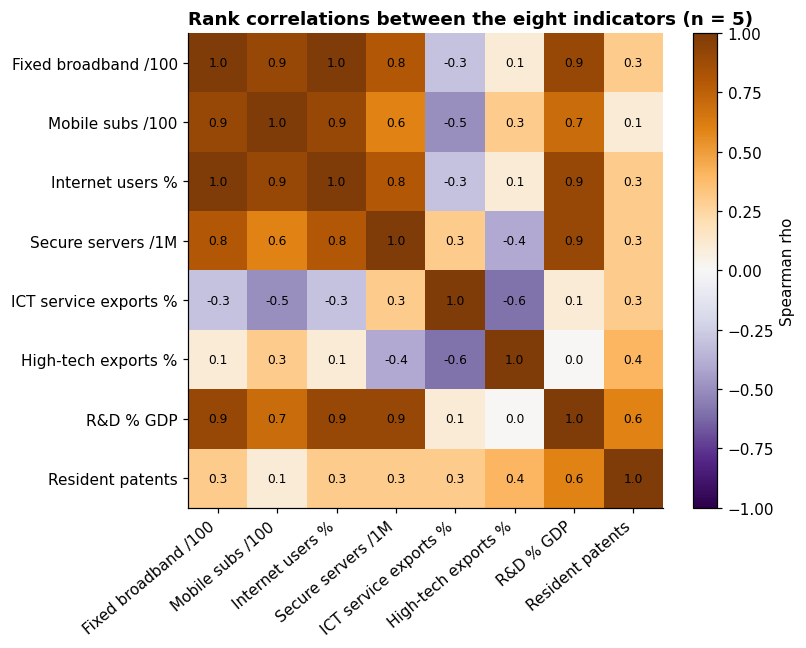

In [17]:
corr = x.rename(columns=SHORT).corr(method='spearman')
fig, ax = plt.subplots(figsize=(7.5, 6))
im = ax.imshow(corr.values, cmap='PuOr_r', vmin=-1, vmax=1)
ax.set_xticks(range(8), corr.columns, rotation=40, ha='right'); ax.set_yticks(range(8), corr.index)
for a in range(8):
    for b in range(8):
        ax.text(b, a, f'{corr.values[a, b]:.1f}', ha='center', va='center', fontsize=8)
fig.colorbar(im, ax=ax, label='Spearman rho')
ax.set_title('Rank correlations between the eight indicators (n = 5)', loc='left', fontweight='bold')
plt.tight_layout(); plt.show()

**Relevant relationships.**
- **Fixed broadband ↔ internet use (ρ = 1.0, r = 0.98).** The five countries rank identically on both, as shown in chart Q4.
- **R&D ↔ fixed broadband and ↔ secure servers (ρ = 0.9).** Countries that invest more in R&D also have denser digital infrastructure.
- **ICT service exports correlate negatively with connectivity (ρ ≈ −0.3 to −0.5).** This is driven by India, and shows that digital trade specialisation and domestic connectivity are different dimensions.

**Why this is not causation, and what would be needed.** The strong broadband–use association could come from a third factor that drives both (income per person, urbanisation, education, prices). Reverse causality is also possible: people who already use the internet demand fixed lines. To defend a causal link we would need:
1. A panel of many countries over many years, not a five-country snapshot.
2. Controls for income, education, urbanisation and prices.
3. Time ordering: does broadband growth come *before* the rise in use?
4. A credible identification strategy, such as a natural experiment (for example, a regional broadband rollout programme compared with similar regions that did not receive it), difference-in-differences or instrumental variables.

## 10. Digital gap

**Mexico's principal digital gap against the other four economies is in innovation and digital value capture.** Mexico is last of five in R&D expenditure (0.27% of GDP, 2023), resident patent applications (1,117, 2021), ICT service exports (5.1% of service exports, 2025) and secure servers (532 per million, 2024).

In [18]:
rank = x.rank(ascending=False).astype(int)
tbl = pd.DataFrame({'Mexico value': x.loc['Mexico'], 'Mexico rank (of 5)': rank.loc['Mexico'],
                    'Brazil value': x.loc['Brazil'], 'best of five': x.max(), 'best country': x.idxmax()})
tbl.index = [SHORT[i] for i in INDICATORS]
tbl.round(2)

,Mexico value,Mexico rank (of 5),Brazil value,best of five,best country
Fixed broadband /100,21.74,4,24.08,47.80,South Korea
Mobile subs /100,116.49,3,101.93,172.52,South Korea
Internet users %,83.12,4,84.46,97.90,South Korea
Secure servers /1M,531.66,5,6941.17,177933.60,Finland
ICT service exports %,5.09,5,13.67,48.60,India
High-tech exports %,19.30,2,11.11,36.26,South Korea
R&D % GDP,0.27,5,1.19,4.94,South Korea
Resident patents,1117.00,5,4666.00,186245.00,South Korea


| Dimension | What our data show for Mexico | Assessment |
|---|---|---|
| **Availability** | Mobile 116.5 subscriptions per 100 (3rd); fixed broadband 21.7 per 100 (4th). No direct measure of network coverage in the eight indicators | Moderate; fixed networks lag |
| **Access** | 83.1% of people use the internet (4th, 1.3 points below Brazil); about one in six people is still offline | Moderate |
| **Affordability** | Not measured by the eight indicators. Price data would be needed (e.g., ITU price baskets as % of GNI per capita) | Unknown with this data |
| **Quality** | Secure servers 532 per million (5th). This is only a proxy; there is no speed or reliability measure | Weak (proxy) |
| **Capabilities** | R&D 0.27% of GDP (5th; Brazil 1.19%, Korea 4.94%); 1,117 resident patents (5th) | **Weakest dimension** |
| **Outcomes** | ICT service exports 5.1% (5th). High-tech exports 19.3% (2nd), but these are largely assembly for export | Weak in digital services |

The gap widens as we move from *having* connectivity to *creating* and *selling* digital value.

**Why high network coverage does not imply high use or benefit.** Coverage means a signal or a cable reaches an area; use requires that people can and want to use it. Between the two stand:
- the price of the service and of the device;
- digital skills;
- relevant content and services, including in local languages;
- quality and reliability;
- trust.

Mexico illustrates this: it has more mobile subscriptions than people (116.5 per 100), yet about 17% of the population did not use the internet in 2024. Benefit requires even more: using the internet productively (in firms, public services, education) is a further step that none of the connectivity indicators measures.

## 11. Readiness for Artificial Intelligence: the 4C framework

| Dimension | Indicators we have | Coverage |
|---|---|---|
| **Connectivity**: infrastructure, networks, access | Fixed broadband, mobile subscriptions, internet users | Good |
| **Compute**: computing capacity, cloud, data centres | Secure servers (only a partial proxy for hosting capacity) | Very limited |
| **Context**: data, languages, applications, relevant resources | None directly | Missing |
| **Competency**: skills to adopt, adapt and develop technology | R&D expenditure and resident patents (indirect proxies of technical capacity) | Partial |

**Is this information enough to say that any country is prepared to develop and use advanced AI systems?** No. The indicators cover connectivity well, but compute and context are almost absent and competency is only indirectly measured. South Korea looks strongest on every dimension we can observe, but even for South Korea this data cannot establish AI readiness.

**Additional information needed:**
- data-centre capacity (MW), cloud regions and access to GPUs or other accelerators;
- price and reliability of electricity;
- availability of open data and of local-language data and models;
- AI and ICT skills of the workforce (graduates in STEM and ICT, specialists);
- firm-level adoption of AI and cloud services;
- AI governance and data-protection frameworks.

## 12. Final diagnosis

**1. How does Mexico compare?** Mexico ranks 5th of 5 on the Digital Readiness Score (0.22), behind South Korea (0.84), Finland (0.55), Brazil (0.31) and India (0.27). It belongs to a lower group with Brazil and India; its last place is robust to most weighting choices, but not all.

**2. Main strength.** Mobile connectivity: 116.5 subscriptions per 100 people (2024), 3rd of 5, ahead of Brazil (101.9) and India (79.4).

**3. Main gap.** Innovation and digital value capture. Mexico is last in R&D (0.27% of GDP), resident patents (1,117), ICT service exports (5.1% of service exports) and secure servers (532 per million).

**4. Most interesting comparison: Brazil.** It is Mexico's closest peer in score, income and region, yet it invests 4.5 times more in R&D (1.19% of GDP), files four times more resident patents (4,666) and has a higher share of ICT service exports (13.7%). Since 2021 it has also overtaken Mexico in fixed broadband (24.1 vs 21.7 per 100).

**5. Main limitation of the data.** The eight indicators are proxies with gaps: they include no measure of affordability, speed, compute or digital skills, and they mix observation years (patents 2021, India's R&D 2020). Because scores are rescaled within five countries, they describe relative positions, not absolute readiness.

In [19]:
nb_cells = json.loads(Path('notebooks/Digital_Economy_Analysis.ipynb').read_text(encoding='utf-8'))['cells']
diagnosis = next(''.join(c['source']) for c in nb_cells if ''.join(c['source']).startswith('## 12. Final diagnosis'))
words = len(diagnosis.split('\n', 1)[1].split())
print(f'Final diagnosis: {words} words (limit 250)')
assert words <= 250

Final diagnosis: 208 words (limit 250)
